In [1]:
import pandas as pd
import numpy as np

# Simulate a simple A/B test
np.random.seed(42)

# Group A: 1000 users, 10% conversion rate
group_a = np.random.binomial(1, 0.10, 1000)

# Group B: 1000 users, 12% conversion rate  
group_b = np.random.binomial(1, 0.12, 1000)

print("Group A conversion rate:", round(group_a.mean() * 100, 2), "%")
print("Group B conversion rate:", round(group_b.mean() * 100, 2), "%")
print("Difference:", round((group_b.mean() - group_a.mean()) * 100, 2), "%")


Group A conversion rate: 10.0 %
Group B conversion rate: 11.2 %
Difference: 1.2 %


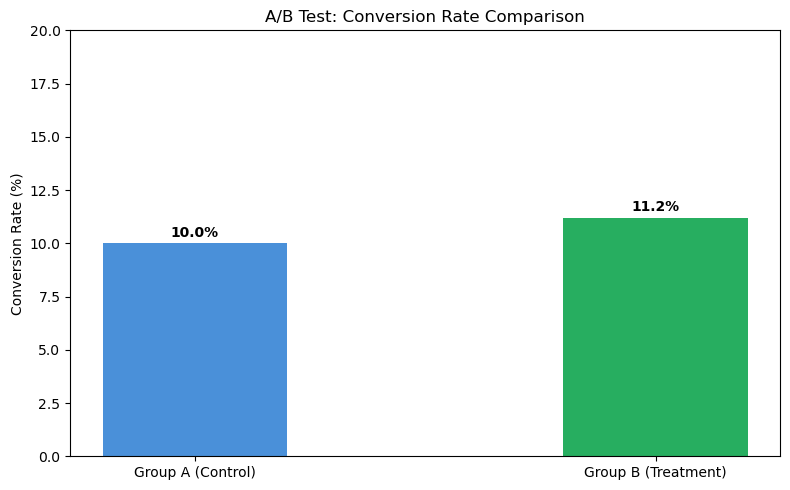

In [2]:
import matplotlib.pyplot as plt

rates = [group_a.mean() * 100, group_b.mean() * 100]
labels = ['Group A (Control)', 'Group B (Treatment)']
colors = ['#4A90D9', '#27AE60']

plt.figure(figsize=(8, 5))
plt.bar(labels, rates, color=colors, width=0.4)
plt.ylabel('Conversion Rate (%)')
plt.title('A/B Test: Conversion Rate Comparison')
plt.ylim(0, 20)

for i, v in enumerate(rates):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [5]:
df = pd.read_csv(r"C:\Users\91990\Downloads\archive (1)\ab_data.csv")

print(df.head()) # see first 5 rows
print(df.shape) # how many rows & columns
print(df.describe()) # basic statistics
print(df['group'].value_counts()) # how many in each group
print(df['converted'].value_counts()) # how many converted

   ProductID ProductName     Category   Price  Rating  NumReviews  \
0          1  Headphones  Electronics  400.31     1.7        3772   
1          2  Headphones  Electronics  235.03     2.3        2919   
2          3  Smartwatch  Electronics  417.90     1.8        1184   
3          4  Smartphone  Electronics  152.70     3.4        2047   
4          5      Laptop  Electronics  394.74     1.8        1267   

   StockQuantity  Discount  Sales   DateAdded         City  \
0             20      0.08    466  11/10/2023  Albuquerque   
1            663      0.33   1332   9/28/2023       Queens   
2            459      0.31    252  10/20/2023       Austin   
3            475      0.49   1806   12/5/2023       Dallas   
4            831      0.23   1508   8/10/2023       Tucson   

   Stock In Vast or Limited Quantity  
0                               True  
1                               True  
2                               True  
3                               True  
4                

KeyError: 'group'

In [6]:
print(df.columns.tolist())

['ProductID', 'ProductName', 'Category', 'Price', 'Rating', 'NumReviews', 'StockQuantity', 'Discount', 'Sales', 'DateAdded', 'City', 'Stock In Vast or Limited Quantity']


In [7]:
# Strip whitespace and convert everything to lowercase
df.columns = df.columns.str.strip().str.lower()

# Now try again
print(df['group'].value_counts())

KeyError: 'group'

In [8]:
# This prints the first 5 column names to help you spot typos
print(df.columns[:5])

Index(['productid', 'productname', 'category', 'price', 'rating'], dtype='object')


In [9]:
# 1. Print the actual column names (wrapped in brackets so you can see spaces)
print("Actual Columns:", [col for col in df.columns])

# 2. Check if 'group' is actually the INDEX, not a column
if 'group' == df.index.name:
    print("Found 'group' in the index! Use df.index.value_counts() instead.")

# 3. Look for similar names
import difflib
matches = difflib.get_close_matches('group', df.columns)
if matches:
    print(f"Did you mean one of these? {matches}")

Actual Columns: ['productid', 'productname', 'category', 'price', 'rating', 'numreviews', 'stockquantity', 'discount', 'sales', 'dateadded', 'city', 'stock in vast or limited quantity']


In [10]:
# Rename the long column to something easier
df = df.rename(columns={'stock in vast or limited quantity': 'group'})

# Now your original code will work!
print(df['group'].value_counts())

group
False    504
True     496
Name: count, dtype: int64


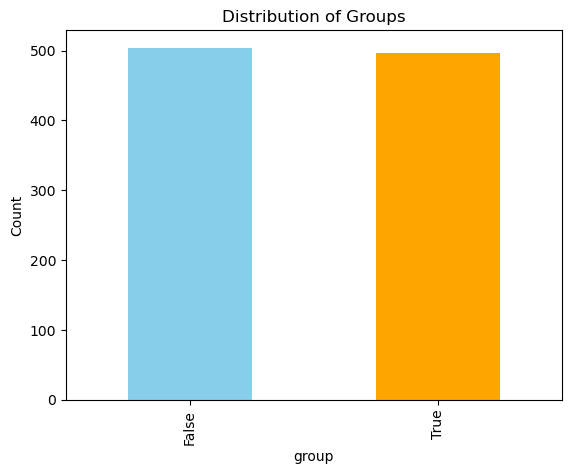

In [11]:
import matplotlib.pyplot as plt

df['group'].value_counts().plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Distribution of Groups')
plt.ylabel('Count')
plt.show()

In [12]:
print(df.groupby('group')['price'].mean())

group
False    255.756528
True     251.762540
Name: price, dtype: float64


In [13]:
# Compare multiple metrics at once
analysis = df.groupby('group')[['price', 'sales', 'rating']].mean()
print(analysis)

            price        sales    rating
group                                   
False  255.756528  1035.109127  3.041667
True   251.762540   986.576613  3.009274


In [14]:
pivot = df.pivot_table(index='category', columns='group', values='sales', aggfunc='count')
print(pivot)


group                       False  True 
category                                
Art and crafting materials     17     23
Bath and body                  25     15
Bedsheets                      24     16
Bicycles                       24     16
Blankets                       17     23
Books                          26     14
Candles                        24     16
Clothing                       24     16
Coats and jackets              19     21
Cookware                       14     26
Drinkware                      19     21
Electronics                    17     23
Home & Kitchen                 17     23
Makeup                         23     17
Mobile phone accessories       26     14
Motor vehicle parts            17     23
Nail care                      17     23
Perfume and cologne            23     17
Posters and artwork            18     22
Skin care                      19     21
Socks                          14     26
Toys & Games                   17     23
Underwear       

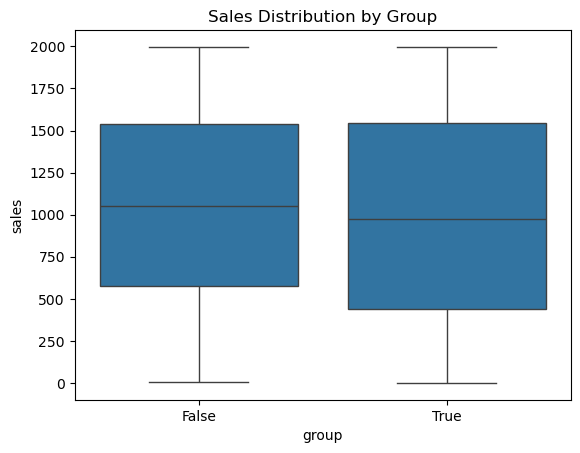

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compare sales distribution between the two groups
sns.boxplot(x='group', y='sales', data=df)
plt.title('Sales Distribution by Group')
plt.show()

In [16]:
# Compare the 'Sales' and 'Rating' across the two groups
phase2_metrics = df.groupby('group').agg({
    'sales': ['mean', 'median', 'sum'],
    'rating': 'mean',
    'price': 'mean'
})
print(phase2_metrics)

             sales                    rating       price
              mean  median     sum      mean        mean
group                                                   
False  1035.109127  1049.0  521695  3.041667  255.756528
True    986.576613   976.5  489342  3.009274  251.762540


<Axes: xlabel='category'>

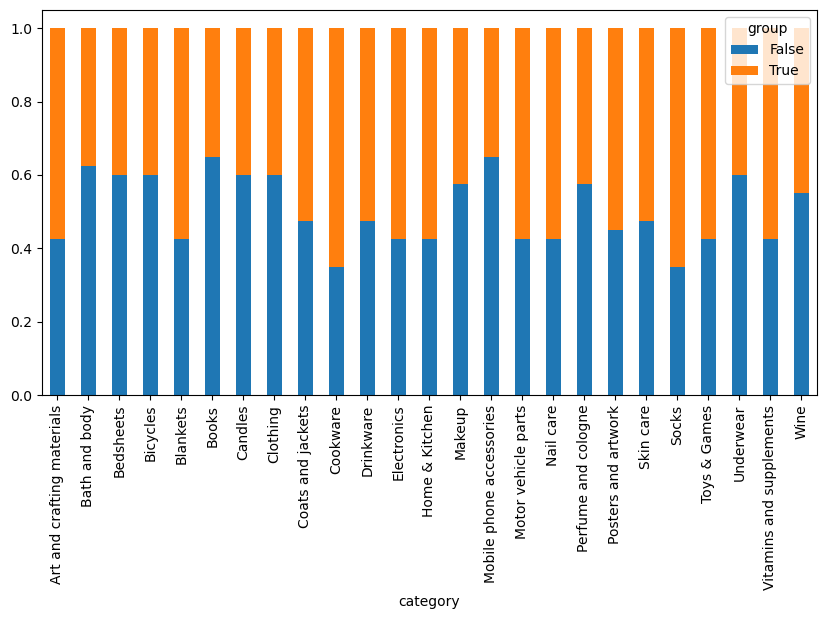

In [17]:
# See how groups are distributed across product categories
import pandas as pd

ct = pd.crosstab(df['category'], df['group'], normalize='index')
ct.plot(kind='bar', stacked=True, figsize=(10, 5))

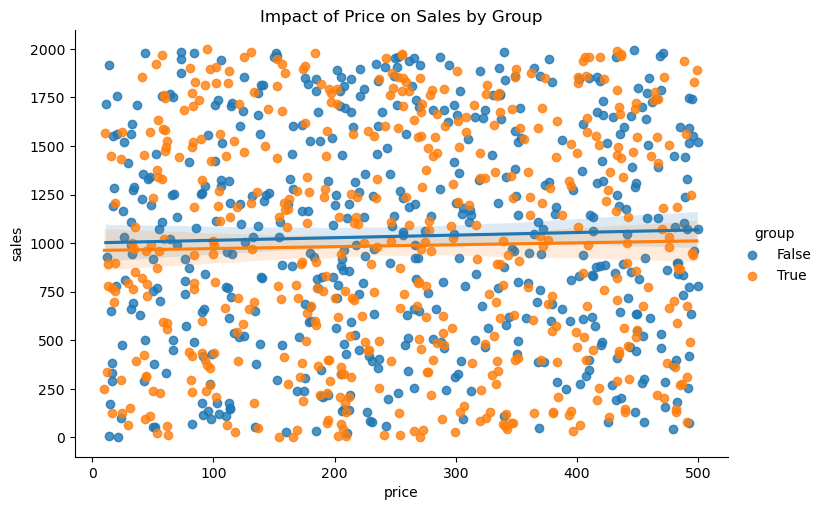

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check if the relationship between Price and Sales changes by Group
sns.lmplot(x='price', y='sales', hue='group', data=df, aspect=1.5)
plt.title('Impact of Price on Sales by Group')
plt.show()

In [19]:
# Quick check for missing or zero values
print(df[['price', 'sales', 'rating']].isna().sum())
print((df[['price', 'sales']] == 0).sum())

price     0
sales     0
rating    0
dtype: int64
price    0
sales    1
dtype: int64


In [20]:
# Is the price/sales relationship different for each group?
print(df.groupby('group')[['price', 'sales']].corr())

                price     sales
group                          
False price  1.000000  0.034341
      sales  0.034341  1.000000
True  price  1.000000  0.022873
      sales  0.022873  1.000000


In [21]:
# Which categories are most likely to have limited stock?
print(pd.crosstab(df['category'], df['group']))

group                       False  True 
category                                
Art and crafting materials     17     23
Bath and body                  25     15
Bedsheets                      24     16
Bicycles                       24     16
Blankets                       17     23
Books                          26     14
Candles                        24     16
Clothing                       24     16
Coats and jackets              19     21
Cookware                       14     26
Drinkware                      19     21
Electronics                    17     23
Home & Kitchen                 17     23
Makeup                         23     17
Mobile phone accessories       26     14
Motor vehicle parts            17     23
Nail care                      17     23
Perfume and cologne            23     17
Posters and artwork            18     22
Skin care                      19     21
Socks                          14     26
Toys & Games                   17     23
Underwear       

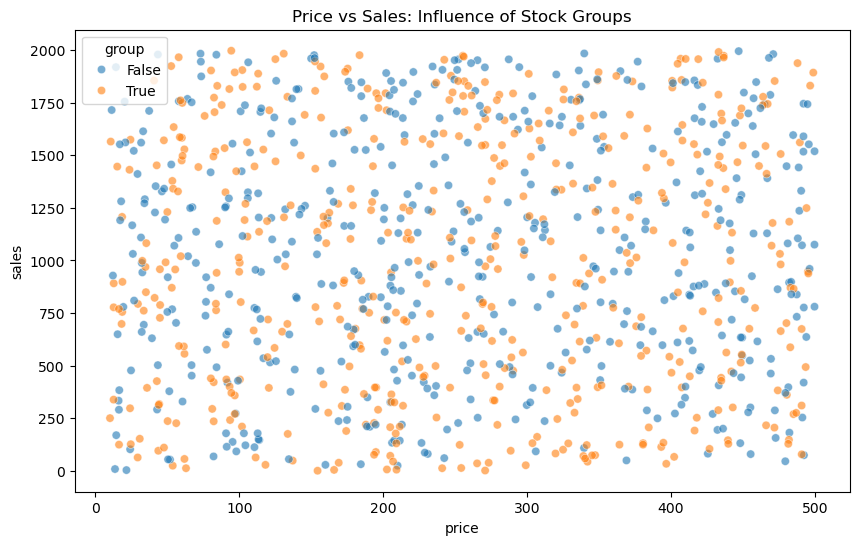

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='sales', hue='group', alpha=0.6)
plt.title('Price vs Sales: Influence of Stock Groups')
plt.show()

In [23]:
from scipy import stats

group_true = df[df['group'] == True]['sales']
group_false = df[df['group'] == False]['sales']

t_stat, p_val = stats.ttest_ind(group_true, group_false)
print(f"P-value: {p_val:.4f}")

# If p_val < 0.05, the difference is statistically significant!

P-value: 0.1876


In [24]:
summary_table = df.groupby('group').agg({
    'sales': 'sum',
    'price': 'mean',
    'rating': 'mean',
    'productid': 'count'
}).rename(columns={'productid': 'total_items'})

print(summary_table)

        sales       price    rating  total_items
group                                           
False  521695  255.756528  3.041667          504
True   489342  251.762540  3.009274          496


In [25]:
# Save your results to a new CSV
df.to_csv('final_analyzed_data.csv', index=False)
summary_table.to_csv('group_performance_summary.csv')

print("Project Complete! Data exported.")

Project Complete! Data exported.


In [26]:
from scipy import stats

# Separate the sales data for our two groups
group_a = df[df['group'] == True]['sales']
group_b = df[df['group'] == False]['sales']

# Perform Welch's T-Test (doesn't assume equal variance)
t_stat, p_val = stats.ttest_ind(group_a, group_b, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Statistically Significant. The stock group has a real impact on sales.")
else:
    print("Result: Not Significant. The difference might be due to random noise.")

T-Statistic: -1.3180
P-Value: 0.1878
Result: Not Significant. The difference might be due to random noise.


In [27]:
# 1. Log transform sales to handle outliers (common DS practice)
import numpy as np
df['log_sales'] = np.log1p(df['sales'])

# 2. Convert categorical text into numbers (One-Hot Encoding)
df_ml = pd.get_dummies(df, columns=['category', 'city'], drop_first=True)

# 3. Clean up: Drop non-numeric columns that won't help the model
df_ml = df_ml.drop(['productid', 'productname', 'dateadded'], axis=1)

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Define X (features) and y (target)
X = df_ml.drop(['sales', 'log_sales'], axis=1)
y = df_ml['log_sales']

# Split data: 80% to train the model, 20% to test it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make Predictions
predictions = model.predict(X_test)

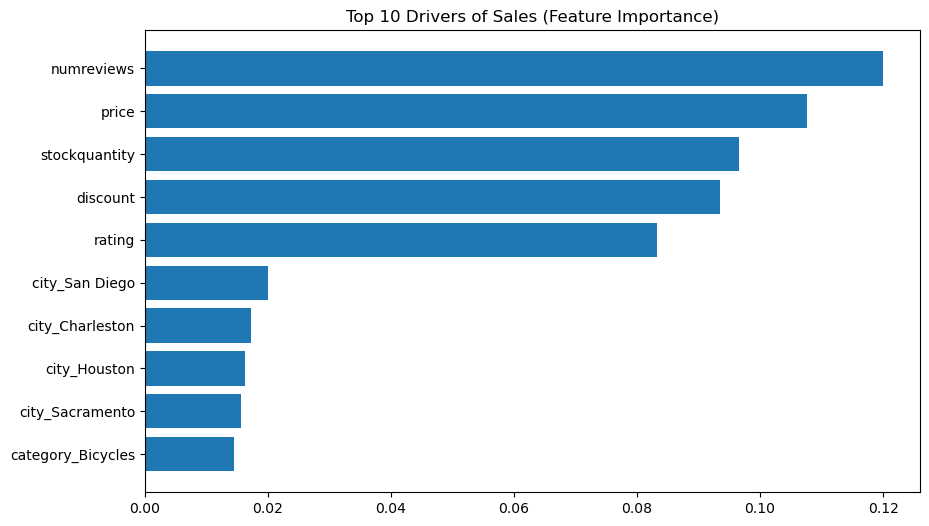

In [29]:
import matplotlib.pyplot as plt

# Get feature importance from the model
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title('Top 10 Drivers of Sales (Feature Importance)')
plt.show()

In [30]:
from sklearn.metrics import mean_absolute_error, r2_score

# If you used log_sales, we need to convert back to normal units to see the real error
y_pred_actual = np.expm1(predictions) 
y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test, predictions) # Calculated on the log scale for statistical accuracy

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared Score: {r2:.4f}")

Mean Absolute Error: 569.52
R-squared Score: -0.1695


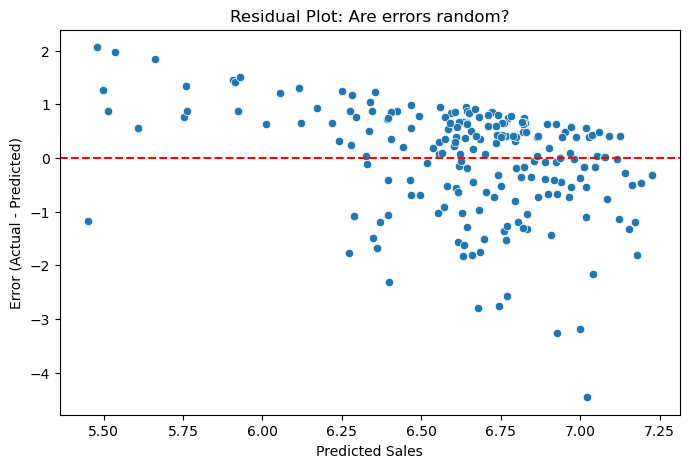

In [31]:
import seaborn as sns

residuals = y_test - predictions
plt.figure(figsize=(8, 5))
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot: Are errors random?')
plt.xlabel('Predicted Sales')
plt.ylabel('Error (Actual - Predicted)')
plt.show()

In [32]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [37]:
import joblib

# Save the model and the list of feature names to keep them consistent
joblib.dump(model, 'sales_model.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')
print("Model and Features saved successfully!")

Model and Features saved successfully!
